In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np

# Фиксируем случайное зерно для воспроизводимости
np.random.seed(42)

# 1. Загрузка данных
# Предполагается, что CSV-файл находится в текущей среде (замените 'data.csv' на путь к файлу при необходимости).
df = pd.read_csv('data.csv', sep=';', decimal=',', parse_dates=['Datetime'], encoding='cp1251')

# Переименование столбцов для удобства (убираем лишние символы, единицы измерения)
df.columns = ['Datetime', 'Radon', 'Temperature', 'Pressure']

# Сортировка по времени (на случай, если данные неупорядочены) и перенумерация индексов
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)

# Просмотр базовой информации о данных
print("Количество записей:", len(df))
print(df.head(3))        # первые несколько строк
print("Пропущенных значений до обработки:\n", df.isna().sum())

# 2. Преобразование типа даты-времени (если не было преобразовано при чтении)
if not np.issubdtype(df['Datetime'].dtype, np.datetime64):
    df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True, errors='raise')

# Устанавливаем дату-время в качестве индекса для удобства интерполяции по времени
df.set_index('Datetime', inplace=True)

# 3. Обработка пропусков: линейная интерполяция по времени для числовых столбцов
cols_num = ['Radon', 'Temperature', 'Pressure']
df[cols_num] = df[cols_num].interpolate(method='time')

# Если в начале или конце остаются NaN после интерполяции, заполним их ближайшими известными значениями
df[cols_num] = df[cols_num].fillna(method='bfill').fillna(method='ffill')

# Проверяем пропуски после обработки
print("Пропущенных значений после интерполяции:\n", df.isna().sum())

# 4. Обработка выбросов: ограничение методом межквартильного размаха (IQR)
for col in cols_num:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Ограничиваем значения колонки диапазоном [lower_bound, upper_bound]
    df[col] = df[col].clip(lower_bound, upper_bound)

# Выводим диапазон значений после устранения выбросов для контроля
print("\nДиапазон значений после удаления выбросов:")
print(df[cols_num].describe().loc[['min', 'max']])


Количество записей: 8762
           Datetime    Radon  Temperature    Pressure
0   01.01.2021 0:00  30849.0     1.970866  994.455951
1  01.01.2021 10:00  29436.0     1.949401  996.318096
2  01.01.2021 11:00  25934.0     1.927937  995.993886
Пропущенных значений до обработки:
 Datetime        0
Radon           9
Temperature    55
Pressure        0
dtype: int64
Пропущенных значений после интерполяции:
 Radon          0
Temperature    0
Pressure       0
dtype: int64

Диапазон значений после удаления выбросов:
       Radon  Temperature     Pressure
min    508.0    -1.354161   958.782100
max  38533.0     8.338097  1011.087849


<ipython-input-1-d49f254c813e>:36: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[cols_num] = df[cols_num].fillna(method='bfill').fillna(method='ffill')


In [2]:
# 5. Создание новых признаков временного ряда
# Разности (градиенты) радона
df['radon_diff1'] = df['Radon'].diff(periods=1)    # изменение радона за один шаг
df['radon_diff17'] = df['Radon'].diff(periods=17)  # ~изменение за сутки (17 шагов ~ 24 часа)

# Скользящие средние радона (moving average) на разных окнах
df['radon_ma3']  = df['Radon'].rolling(window=3).mean()    # ~4.25 часа (3 шага)
df['radon_ma6']  = df['Radon'].rolling(window=6).mean()    # ~8.5 часов
df['radon_ma17'] = df['Radon'].rolling(window=17).mean()   # ~24 часа
df['radon_ma34'] = df['Radon'].rolling(window=34).mean()   # ~48 часов (≈2 суток)

# Календарные признаки
df['month']      = df.index.month     # месяц (1-12)
df['hour']       = df.index.hour      # час суток (0-23)
df['day_of_week']= df.index.weekday   # день недели (0 = понедельник, ... 6 = воскресенье)

# После генерации первых разностей/средних появятся NaN в начале ряда - заполним их ближайшими значениями
df.fillna(method='bfill', inplace=True)

print("Признаки сгенерированы. Теперь колонки данных:\n", list(df.columns))

# 6. Параметры горизонта прогноза и длины истории
HORIZON_STEPS = 51   # горизонт прогноза ~3 суток вперёд (51*85мин ≈ 3 дня)
SEQ_LENGTH   = 68    # длина последовательности входных данных ~4 суток истории

# Определяем индексы, доступные для формирования примеров (учитывая горизонты и историю)
total_points = len(df)
start_index = HORIZON_STEPS + SEQ_LENGTH - 1
if start_index >= total_points:
    raise ValueError("Недостаточно данных для выбранных HORIZON_STEPS и SEQ_LENGTH.")
target_indices = list(range(start_index, total_points))
print(f"Общее количество примеров для моделирования: {len(target_indices)}")

# Разделение на обучающую, валидационную и тестовую выборки (70% / 15% / 15%)
train_size = int(0.70 * len(target_indices))
val_size   = int(0.15 * len(target_indices))
test_size  = len(target_indices) - train_size - val_size

train_idx = target_indices[:train_size]
val_idx   = target_indices[train_size: train_size + val_size]
test_idx  = target_indices[train_size + val_size:]

print(f"Размер обучающей выборки: {len(train_idx)}")
print(f"Размер валидационной выборки: {len(val_idx)}")
print(f"Размер тестовой выборки: {len(test_idx)}")

# 7. Формирование наборов X и y для каждой выборки
# Выбираем признаки для табличной модели (градиентный бустинг) на момент времени i
tab_features = ['Radon', 'Temperature', 'Pressure',
                'radon_diff1', 'radon_diff17',
                'radon_ma3', 'radon_ma6', 'radon_ma17', 'radon_ma34',
                'month', 'hour', 'day_of_week']

X_train_tab, X_val_tab, X_test_tab = [], [], []
X_train_seq, X_val_seq, X_test_seq = [], [], []
y_train, y_val, y_test = [], [], []

for idx_list, X_tab_list, X_seq_list, y_list in [
    (train_idx, X_train_tab, X_train_seq, y_train),
    (val_idx,   X_val_tab,   X_val_seq,   y_val),
    (test_idx,  X_test_tab,  X_test_seq,  y_test)
]:
    for j in idx_list:
        # Определяем момент i, от которого делается прогноз на j = i + HORIZON_STEPS
        i = j - HORIZON_STEPS
        # Табличные признаки в момент i
        X_tab_list.append(df.iloc[i][tab_features].values.astype(float))
        # Последовательность длины SEQ_LENGTH: Radon, Temperature, Pressure от (i-SEQ_LENGTH+1) до i включительно
        seq_start = i - SEQ_LENGTH + 1
        seq_slice = df.iloc[seq_start: i+1][['Radon', 'Temperature', 'Pressure']].values.astype(float)
        X_seq_list.append(seq_slice)
        # Целевой признак: концентрация радона в момент j (через горизонт от i)
        y_list.append(df.iloc[j]['Radon'])

# Преобразуем списки в numpy массивы
X_train_tab = np.array(X_train_tab);   X_val_tab = np.array(X_val_tab);   X_test_tab = np.array(X_test_tab)
X_train_seq = np.array(X_train_seq);   X_val_seq = np.array(X_val_seq);   X_test_seq = np.array(X_test_seq)
y_train = np.array(y_train);           y_val = np.array(y_val);           y_test = np.array(y_test)

# Контрольные выводы форматов полученных массивов
print("\nФорматы выборок:")
print("X_train_tab:", X_train_tab.shape, "| X_train_seq:", X_train_seq.shape, "| y_train:", y_train.shape)
print("X_val_tab:  ", X_val_tab.shape,   "| X_val_seq:  ", X_val_seq.shape,   "| y_val:", y_val.shape)
print("X_test_tab: ", X_test_tab.shape,  "| X_test_seq:", X_test_seq.shape,  "| y_test:", y_test.shape)

# 8. Масштабирование (стандартизация) последовательных признаков для LSTM
# Обучим StandardScaler на обучающих последовательностях (объединяем по временной оси)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_seq_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])  # объединяем все временные шаги подряд
scaler.fit(X_train_seq_flat)

# Применим масштабирование к последовательностям каждой выборки
X_train_seq = scaler.transform(X_train_seq_flat).reshape(X_train_seq.shape)
X_val_seq   = scaler.transform(X_val_seq.reshape(-1, X_val_seq.shape[-1])).reshape(X_val_seq.shape)
X_test_seq  = scaler.transform(X_test_seq.reshape(-1, X_test_seq.shape[-1])).reshape(X_test_seq.shape)

print("\nМасштабирование признаков для LSTM выполнено.")


Признаки сгенерированы. Теперь колонки данных:
 ['Radon', 'Temperature', 'Pressure', 'radon_diff1', 'radon_diff17', 'radon_ma3', 'radon_ma6', 'radon_ma17', 'radon_ma34', 'month', 'hour', 'day_of_week']
Общее количество примеров для моделирования: 8644
Размер обучающей выборки: 6050
Размер валидационной выборки: 1296
Размер тестовой выборки: 1298


<ipython-input-2-5657ab679da6>:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)



Форматы выборок:
X_train_tab: (6050, 12) | X_train_seq: (6050, 68, 3) | y_train: (6050,)
X_val_tab:   (1296, 12) | X_val_seq:   (1296, 68, 3) | y_val: (1296,)
X_test_tab:  (1298, 12) | X_test_seq: (1298, 68, 3) | y_test: (1298,)

Масштабирование признаков для LSTM выполнено.


In [3]:
!pip install xgboost -q
from xgboost import XGBRegressor
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Softmax, Multiply, Lambda, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# 9. Инициализация и обучение модели XGBoost
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
# Обучаем XGBoost на обучающих данных, контролируя качество по валидации (с ранней остановкой)
xgb_model.fit(
    X_train_tab, y_train,
    eval_set=[(X_val_tab, y_val)],
    verbose=False
)
# Выводим информацию о завершении
print("XGBoost: обучение завершено.")

# 10. Построение нейронной сети LSTM с механизмом внимания
SEQ_FEATS = X_train_seq.shape[2]  # количество признаков в последовательности (3)

# Входной слой последовательности
sequence_input = Input(shape=(SEQ_LENGTH, SEQ_FEATS), name='sequence_input')

# LSTM с возвратом последовательности скрытых состояний
lstm_out = LSTM(64, activation='tanh', return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(sequence_input)

# Механизм внимания: вычисление весов важности для каждого шага LSTM-выхода
score_seq = Dense(1, activation=None)(lstm_out)       # необработанные оценки (batch, seq_len, 1)
attention_weights = Softmax(axis=1)(score_seq)        # нормированные веса через Softmax по времени
context_vector = Multiply()([lstm_out, attention_weights])  # применение весов: акцентируем важные шаги
context_vector = Lambda(lambda x: tf.reduce_sum(x, axis=1))(context_vector)  # суммируем по временной оси -> контекст (batch, 64)

# Полносвязный блок и выход
dense_layer = Dense(32, activation='relu')(context_vector)
radon_pred = Dense(1, activation='linear')(dense_layer)

# Определяем модель
lstm_model = Model(inputs=sequence_input, outputs=radon_pred)
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Краткое описание модели
lstm_model.summary()

# Обучение LSTM модели на обучающей выборке с валидацией и ранней остановкой
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = lstm_model.fit(
    X_train_seq, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_val_seq, y_val),
    callbacks=[early_stop],
    verbose=0
)
print("LSTM с attention: обучение завершено. Эпох выполнено:", len(history.history['loss']))


XGBoost: обучение завершено.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 68, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 68, 64)    │     17,408 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 68, 1)     │         65 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 68, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 68, 64)    │          0 │ lstm[0][0],       │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,586 (76.51 KB)

 Trainable params: 19,586 (76.51 KB)

 Non-trainable params: 0 (0.00 B)

LSTM с attention: обучение завершено. Эпох выполнено: 42


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Метамодель (стеккинг) обучена на предсказаниях XGBoost и LSTM.
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Метрики на тестовой выборке: MAE = 7443.79, RMSE = 9607.35, R^2 = -0.092


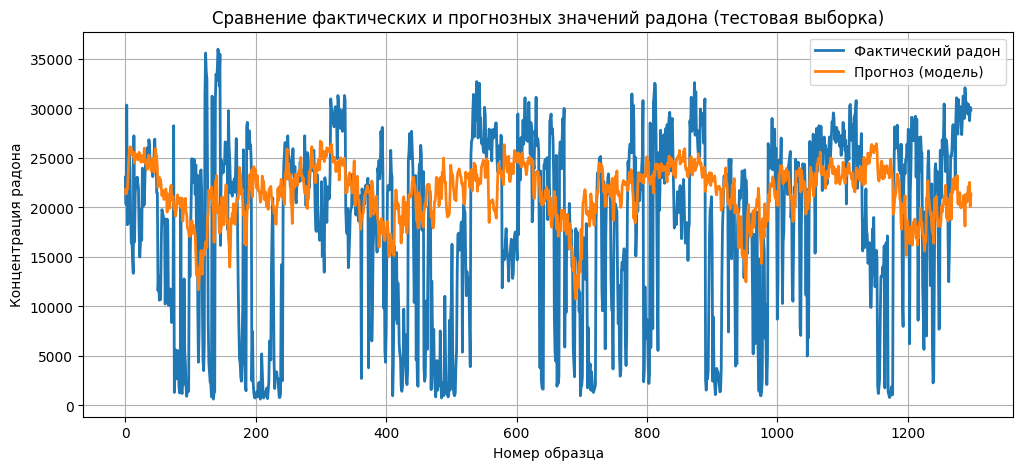

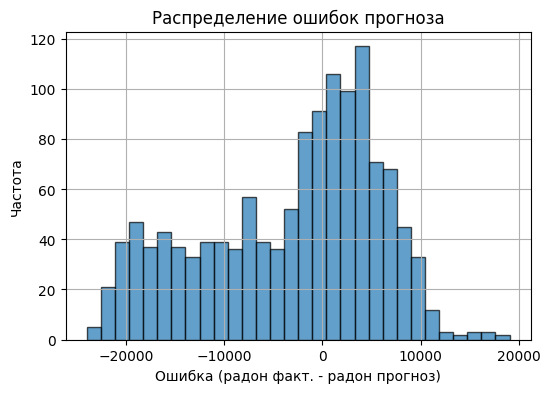

Финальная модель сохранена в 'stacking_model_improved.h5'. Метрики сохранены в 'metrics_improved.json'.


In [4]:
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# 11. Предсказания базовых моделей на валидационной выборке
val_preds_xgb = xgb_model.predict(X_val_tab)
val_preds_lstm = lstm_model.predict(X_val_seq).reshape(-1)

# Формируем обучающие данные для метамодели
X_meta_train = np.column_stack([val_preds_xgb, val_preds_lstm])
y_meta_train = y_val  # фактические значения радона на валидации

# Инициализируем и обучаем метамодель (небольшая полносвязная сеть)
meta_model = Sequential()
meta_model.add(Dense(4, activation='relu', input_shape=(2,)))  # скрытый слой на 4 нейрона
meta_model.add(Dense(1, activation='linear'))                  # выходной нейрон

meta_model.compile(optimizer='adam', loss='mse')
meta_model.fit(X_meta_train, y_meta_train, epochs=20, batch_size=8, verbose=0)
print("Метамодель (стеккинг) обучена на предсказаниях XGBoost и LSTM.")

# 12. Оценка на тестовой выборке
# Предсказания базовых моделей на тесте
test_preds_xgb = xgb_model.predict(X_test_tab)
test_preds_lstm = lstm_model.predict(X_test_seq).reshape(-1)

# Предсказания финальной (стекинговой) модели на тесте
X_meta_test = np.column_stack([test_preds_xgb, test_preds_lstm])
final_preds = meta_model.predict(X_meta_test).reshape(-1)

# Вычисление метрик
mae_value = mean_absolute_error(y_test, final_preds)
rmse_value = math.sqrt(mean_squared_error(y_test, final_preds))
r2_value = r2_score(y_test, final_preds)
print(f"Метрики на тестовой выборке: MAE = {mae_value:.2f}, RMSE = {rmse_value:.2f}, R^2 = {r2_value:.3f}")

# 13. Визуализация: сравнение предсказанных и фактических значений
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(y_test, label='Фактический радон', linewidth=2)
plt.plot(final_preds, label='Прогноз (модель)', linewidth=2)
plt.title('Сравнение фактических и прогнозных значений радона (тестовая выборка)')
plt.xlabel('Номер образца')
plt.ylabel('Концентрация радона')
plt.legend()
plt.grid(True)
plt.show()

# Визуализация распределения ошибок (остатков)
residuals = y_test - final_preds
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Распределение ошибок прогноза')
plt.xlabel('Ошибка (радон факт. - радон прогноз)')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

# 14. Сохранение модели и метрик
# Сохраняем метрики в JSON
metrics = {"mae": float(mae_value), "rmse": float(rmse_value), "r2": float(r2_value)}
with open('metrics_improved.json', 'w') as f:
    json.dump(metrics, f)

# Сохраняем метамодель стекинга в формате .h5
meta_model.save('stacking_model_improved.h5')
print("Финальная модель сохранена в 'stacking_model_improved.h5'. Метрики сохранены в 'metrics_improved.json'.")
